# Notebook 15: MMLU Benchmarking for Utility Preservation

So far, my utility evaluation (Notebook 14) has relied entirely on perplexity metrics — retain set perplexity and qualitative generation checks. These are useful, but they only tell me whether the model still produces fluent, low-perplexity text on my specific MUSE-News retain set. They don't tell me whether the model's actual general reasoning ability (the kind my thesis Objective 4 promises to benchmark) survived the unlearning process.

This notebook runs the **MMLU (Massive Multitask Language Understanding)** benchmark on both my base target model and my final Q-Surgical unlearned 4-bit model, so I can directly compare reasoning performance before and after unlearning. If my Grid-Aware Loss and layer-targeted training worked as intended, the MMLU accuracy of the unlearned model should stay close to the base model's accuracy — a large drop would indicate real utility damage that my perplexity metrics alone wouldn't have caught.

**Input:** the base target model (`target_model_fp16`) and my final Q-Surgical model, both loaded in 4-bit for a fair comparison against actual deployment conditions.

**Output:** a per-subject and overall accuracy comparison table, plus a bar chart for my thesis Results chapter.

In [ ]:
!pip install -U datasets bitsandbytes transformers accelerate --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 156.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 51.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


## Loading the MMLU Dataset

MMLU covers 57 subjects (from abstract algebra to professional medicine), each with multiple-choice questions (4 options: A, B, C, D). Running the full benchmark (~14,000 questions) through two 4-bit models on Colab would take a long time, so I'm evaluating on a **representative subset of subjects** rather than the entire benchmark — this keeps runtime manageable while still giving a meaningful signal about general reasoning ability across different domains (STEM, humanities, social science, and "other").

I picked one subject per broad category rather than random subjects, so the subset isn't accidentally skewed toward one type of reasoning.

In [ ]:
from datasets import load_dataset
import pandas as pd

# One subject per broad MMLU category, to get a representative (not random) subset
SUBJECTS = [
    "high_school_mathematics",   # STEM
    "college_biology",           # STEM
    "world_religions",           # Humanities
    "high_school_government_and_politics",  # Social Science
    "professional_medicine",     # Other/Professional
    "moral_scenarios",           # Humanities (known to be a harder subject, good stress test)
]

QUESTIONS_PER_SUBJECT = 50  # subsample per subject to keep total runtime reasonable

all_questions = []

for subject in SUBJECTS:
    ds = load_dataset("cais/mmlu", subject, split="test")
    n = min(QUESTIONS_PER_SUBJECT, len(ds))
    subset = ds.select(range(n))
    for row in subset:
        all_questions.append({
            "subject": subject,
            "question": row["question"],
            "choices": row["choices"],
            "answer": row["answer"]  # integer index: 0=A, 1=B, 2=C, 3=D
        })

mmlu_df = pd.DataFrame(all_questions)
print(f"Loaded {len(mmlu_df)} questions across {len(SUBJECTS)} subjects.")
print(mmlu_df['subject'].value_counts())

README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

high_school_mathematics/test-00000-of-00(…): reconstructing file:   0%|          |  0.00B / 33.7kB            

high_school_mathematics/test-00000-of-00(…): downloading bytes:           |  0.00B            

high_school_mathematics/validation-00000(…): reconstructing file:   0%|          |  0.00B / 6.99kB            

...

moral_scenarios/dev-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/895 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

Loaded 300 questions across 6 subjects.
subject
high_school_mathematics                50
college_biology                        50
world_religions                        50
high_school_government_and_politics    50
professional_medicine                  50
moral_scenarios                        50
Name: count, dtype: int64


## How I'm Scoring Multiple-Choice Answers

The standard way to evaluate MMLU on a language model isn't to have it *generate* an answer in free text (too unreliable to parse) — instead, I format each question with its four options labeled A/B/C/D, then check which single next-token the model assigns the highest probability to: "A", "B", "C", or "D". Whichever letter gets the highest probability is treated as the model's answer, and I compare that against the correct answer index.

This is a 0-shot evaluation (no worked examples given beforehand) — I'm keeping it simple since my goal here is a relative comparison between my base model and my unlearned model, not chasing an absolute state-of-the-art MMLU score.

In [ ]:
import torch
from tqdm import tqdm

LETTERS = ["A", "B", "C", "D"]

def build_mmlu_prompt(question, choices):
    prompt = f"{question}\n"
    for letter, choice in zip(LETTERS, choices):
        prompt += f"{letter}. {choice}\n"
    prompt += "Answer:"
    return prompt

def evaluate_mmlu(model, tokenizer, df, desc="Evaluating MMLU"):
    letter_token_ids = [tokenizer.encode(f" {letter}", add_special_tokens=False)[-1] for letter in LETTERS]

    correct = 0
    results = []

    with torch.no_grad():
        for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
            prompt = build_mmlu_prompt(row['question'], row['choices'])
            input_ids = tokenizer.encode(prompt, return_tensors="pt").to(model.device)

            logits = model(input_ids).logits
            next_token_logits = logits[0, -1, :]

            letter_logits = torch.tensor([next_token_logits[tid].item() for tid in letter_token_ids])
            predicted_idx = torch.argmax(letter_logits).item()

            is_correct = (predicted_idx == row['answer'])
            correct += int(is_correct)

            results.append({
                "subject": row['subject'],
                "predicted": LETTERS[predicted_idx],
                "correct_answer": LETTERS[row['answer']],
                "is_correct": is_correct
            })

    accuracy = correct / len(df)
    results_df = pd.DataFrame(results)
    return accuracy, results_df

## Running Both Models Through MMLU

I'm loading both models in 4-bit, matching the actual deployment condition my thesis is about — the whole point of my research is what happens under real 4-bit quantization, so evaluating utility at fp16 wouldn't be a fair test of what I actually claim to have achieved.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

BASE_MODEL_PATH = "/content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/target_model_fp16"
STAND_UNLEARNED_MODEL_PATH = "/content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/unlearned_model_fp16"
QSURGICAL_MODEL_PATH = "/content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/QAMU1_FP16"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading base model in 4-bit...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH, quantization_config=bnb_config, local_files_only=True, device_map="auto"
)
base_model.eval()

print("Evaluating base model on MMLU...")
base_accuracy, base_results_df = evaluate_mmlu(base_model, tokenizer, mmlu_df, desc="Base model")

# Free memory before loading the second model
del base_model
torch.cuda.empty_cache()
import gc
gc.collect()

print("Loading standered model in 4-bit...")
standard_unl__model = AutoModelForCausalLM.from_pretrained(
    STAND_UNLEARNED_MODEL_PATH, quantization_config=bnb_config, local_files_only=True, device_map="auto"
)
standard_unl__model.eval()

print("Evaluating standered model on MMLU...")
stand_unl_accuracy, stand_unl_results_df = evaluate_mmlu(standard_unl__model, tokenizer, mmlu_df, desc="Base model")

# Free memory before loading the second model
del standard_unl__model
torch.cuda.empty_cache()
import gc
gc.collect()

print("\nLoading Q-Surgical unlearned model in 4-bit...")
qsurgical_model = AutoModelForCausalLM.from_pretrained(
    QSURGICAL_MODEL_PATH, quantization_config=bnb_config, local_files_only=True, device_map="auto"
)
qsurgical_model.eval()

print("Evaluating Q-Surgical model on MMLU...")
qsurgical_accuracy, qsurgical_results_df = evaluate_mmlu(qsurgical_model, tokenizer, mmlu_df, desc="Q-Surgical model")

print(f"\n{'='*50}")
print(f"Base model overall accuracy:       {base_accuracy*100:.8f}%")
print(f"Standardized unlearned model overall accuracy: {stand_unl_accuracy*100:.8f}%")
print(f"Q-Surgical model overall accuracy: {qsurgical_accuracy*100:.8f}%")
print(f"Difference: {(qsurgical_accuracy - base_accuracy)*100:+.8f} percentage points")
print(f"{'='*50}")

Loading base model in 4-bit...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Evaluating base model on MMLU...


Base model: 100%|██████████| 300/300 [00:20<00:00, 14.88it/s]


Loading standered model in 4-bit...


...


Loading Q-Surgical unlearned model in 4-bit...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Evaluating Q-Surgical model on MMLU...


Q-Surgical model: 100%|██████████| 300/300 [00:19<00:00, 15.52it/s]


Base model overall accuracy:       65.00000000%
Standardized unlearned model overall accuracy: 63.33333333%
Q-Surgical model overall accuracy: 63.33333333%
Difference: -1.66666667 percentage points


## Per-Subject Comparison

An overall accuracy number can hide subject-specific damage — it's possible the model does fine on average but got noticeably worse at one particular type of reasoning. I'm breaking this down per subject to check for that before trusting the overall number alone.

                                     Base Model (%)  Q-Surgical Model (%)  \
subject                                                                     
college_biology                                86.0                  82.0   
high_school_government_and_politics            92.0                  80.0   
high_school_mathematics                        30.0                  40.0   
moral_scenarios                                56.0                  48.0   
professional_medicine                          48.0                  54.0   
world_religions                                78.0                  76.0   

                                     Difference (pp)  
subject                                               
college_biology                                 -4.0  
high_school_government_and_politics            -12.0  
high_school_mathematics                         10.0  
moral_scenarios                                 -8.0  
professional_medicine                            6.0 

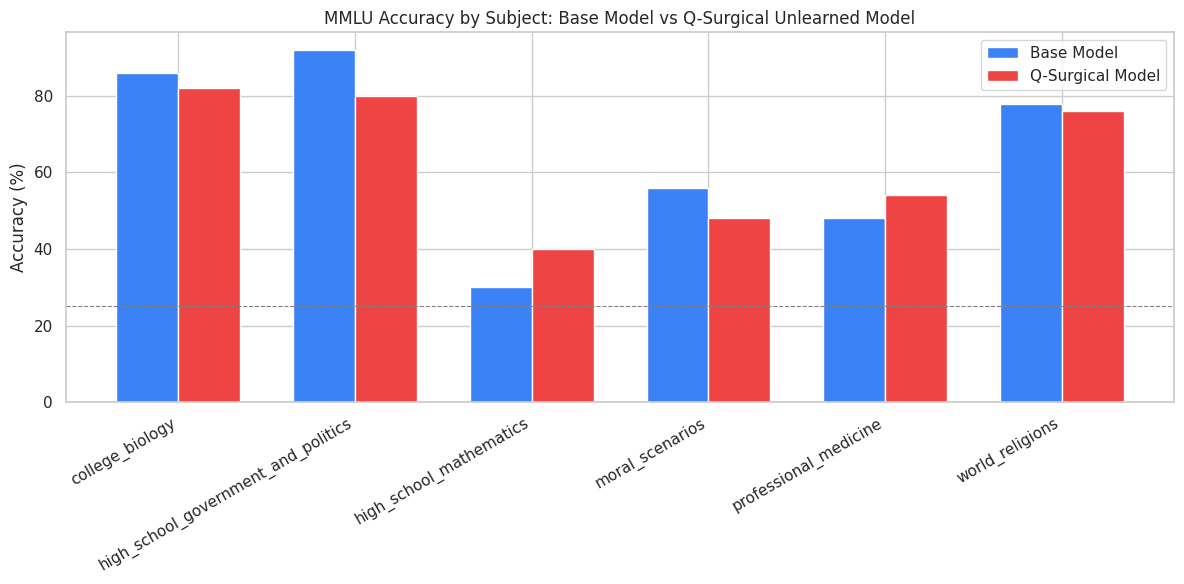

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def per_subject_accuracy(results_df):
    return results_df.groupby('subject')['is_correct'].mean() * 100

base_by_subject = per_subject_accuracy(base_results_df)
qsurgical_by_subject = per_subject_accuracy(qsurgical_results_df)

comparison_df = pd.DataFrame({
    'Base Model (%)': base_by_subject,
    'Q-Surgical Model (%)': qsurgical_by_subject
})
comparison_df['Difference (pp)'] = comparison_df['Q-Surgical Model (%)'] - comparison_df['Base Model (%)']

print(comparison_df.round(2))

# Save for thesis reporting
OUTPUT_CSV_PATH = "/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/processed/mmlu_comparison_results.csv"
comparison_df.to_csv(OUTPUT_CSV_PATH)

# Bar chart: base vs Q-Surgical, per subject
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(comparison_df))
width = 0.35

ax.bar([i - width/2 for i in x], comparison_df['Base Model (%)'], width, label='Base Model', color='#3b82f6')
ax.bar([i + width/2 for i in x], comparison_df['Q-Surgical Model (%)'], width, label='Q-Surgical Model', color='#ef4444')

ax.set_xticks(list(x))
ax.set_xticklabels(comparison_df.index, rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MMLU Accuracy by Subject: Base Model vs Q-Surgical Unlearned Model')
ax.legend()
ax.axhline(25, color='gray', linestyle='--', linewidth=0.8, label='Random guess baseline (25%)')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/processed/mmlu_comparison_chart.pdf", dpi=300, bbox_inches='tight')
plt.show()